In [1]:
# import nessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/workspaces/customer_chrun_prediction/data/processed/clean_customer_churn_dataset.csv')
df.head(2)

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.4,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.2,Month-to-month,Debit,DSL,No,No,2,No


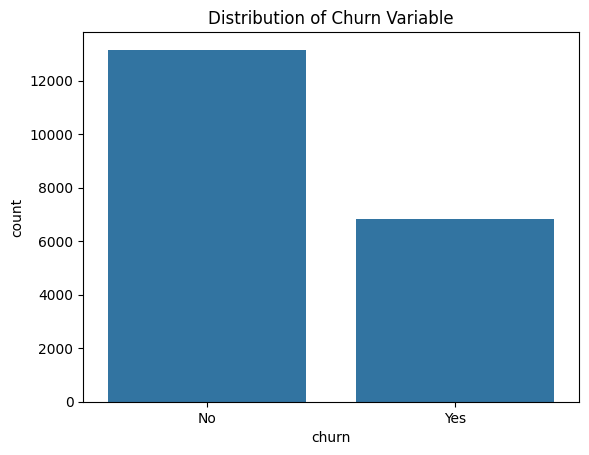

churn
No     65.785
Yes    34.215
Name: proportion, dtype: float64


In [3]:
# Visuliaze the distribution of the target variable
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn Variable')
plt.show()
# Calculate the percentage of churned customers
churn_percentage = df['churn'].value_counts(normalize=True) * 100
print(churn_percentage)

First Point to be consider is data imbalance we will handle it again in feature engineer section

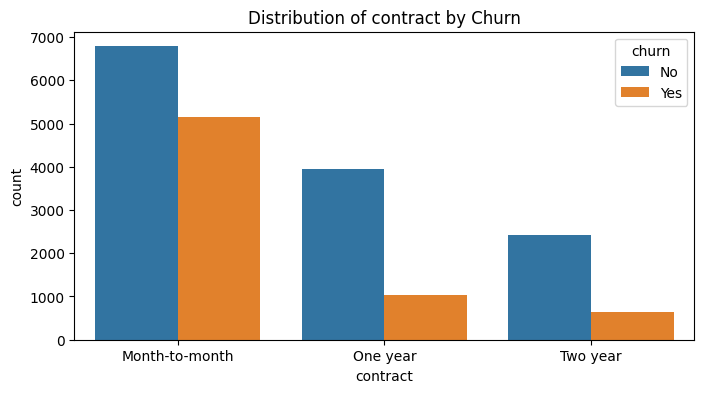

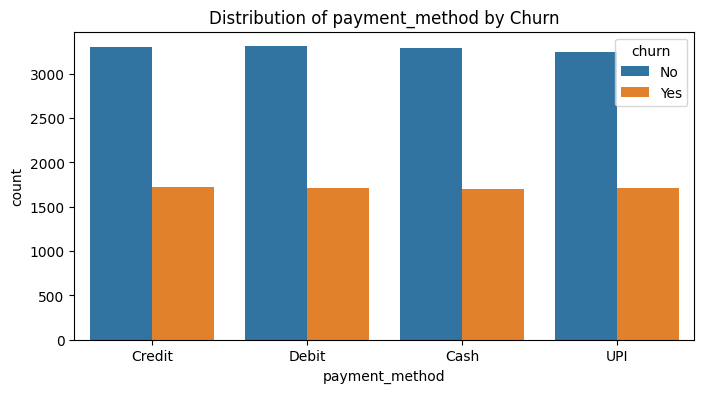

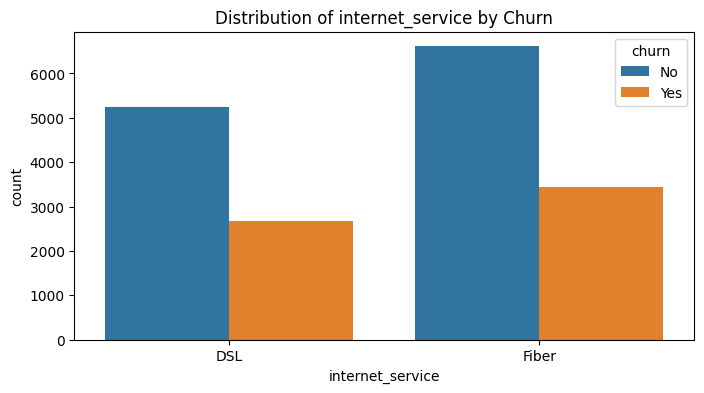

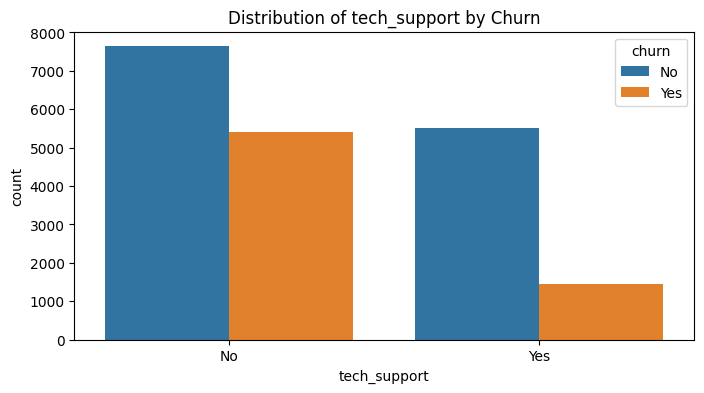

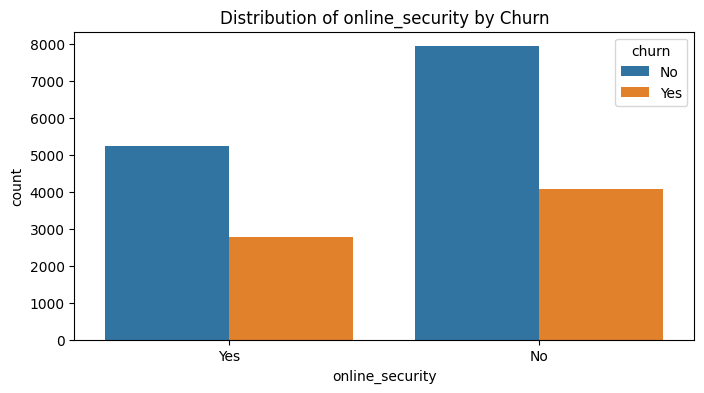

In [4]:
# Visulize the distribution of features
categorical_features = ['contract', 'payment_method', 'internet_service','tech_support','online_security']
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=feature, data=df, hue='churn')
    plt.title(f'Distribution of {feature} by Churn')
    plt.show()

Month to month contact,not received any tech support,clients who doesn't enroll to online security tend to have higher churn.

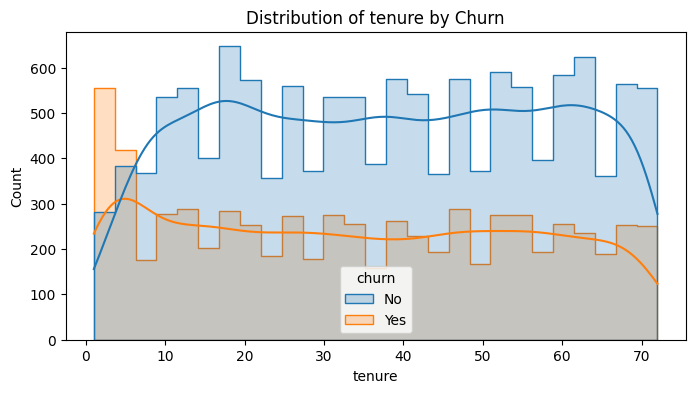

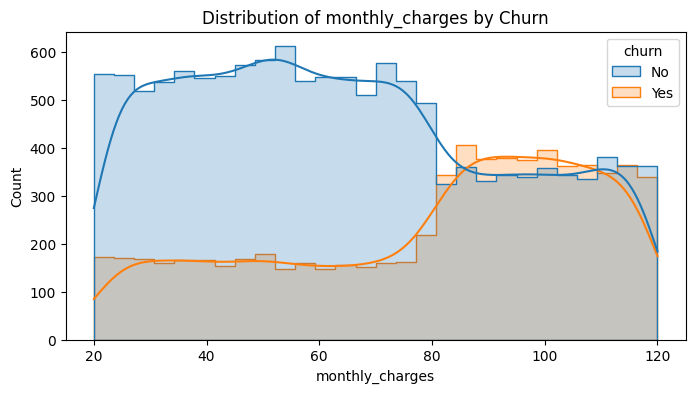

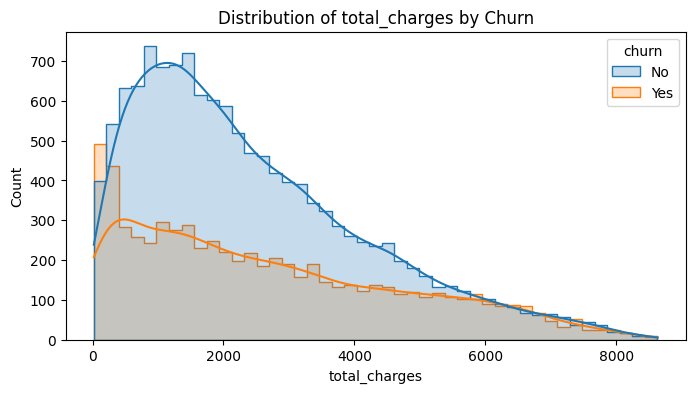

In [5]:
from unicodedata import numeric


numeric_features = ['tenure', 'monthly_charges', 'total_charges']
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, hue='churn', kde=True, element='step')
    plt.title(f'Distribution of {feature} by Churn')
    plt.show()

Clients exhibit the highest churn risk within the first six months of onboarding. After this initial period, churn steadily declines, reaching its lowest point at approximately 36 months (three years), before beginning to rise again. Pricing analysis indicates that customers are more likely to churn when monthly costs exceed $81. Additionally, the data shows a strong inverse relationship between customer spend and churn—clients who invest more in our services, particularly those retained for over three years, demonstrate significantly lower churn rates.

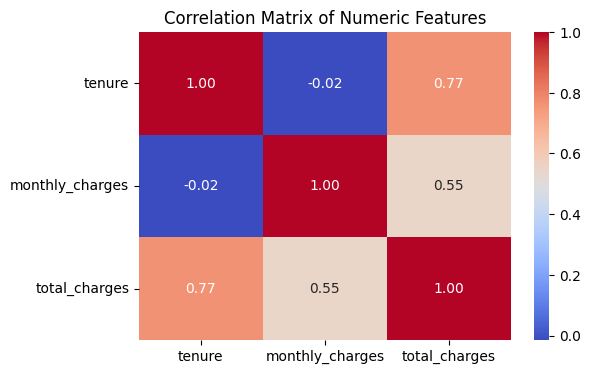

In [8]:
# Check for correlations between numeric features
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()